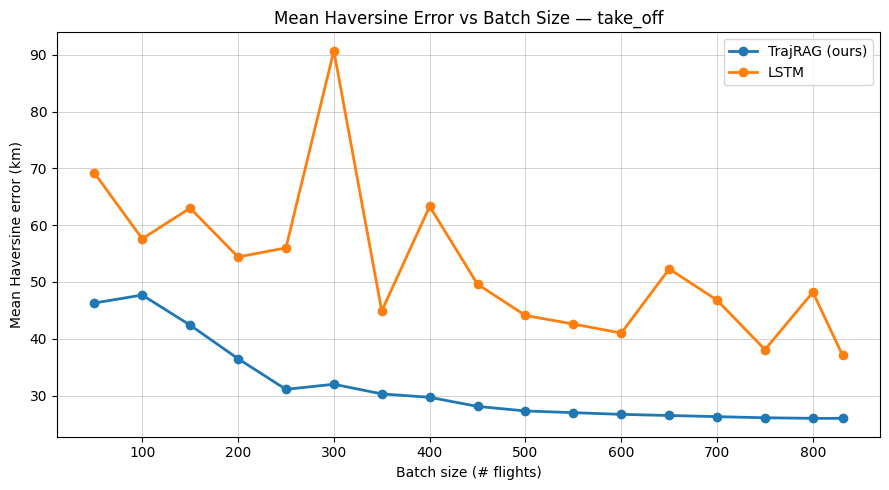

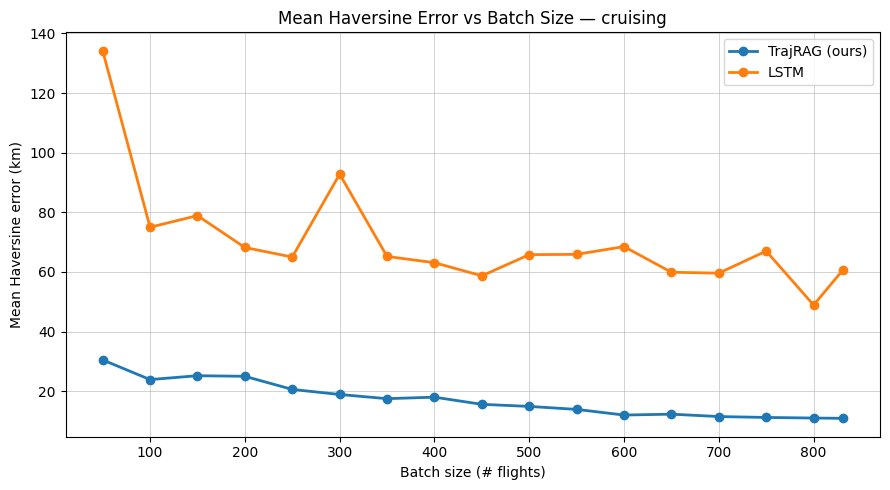

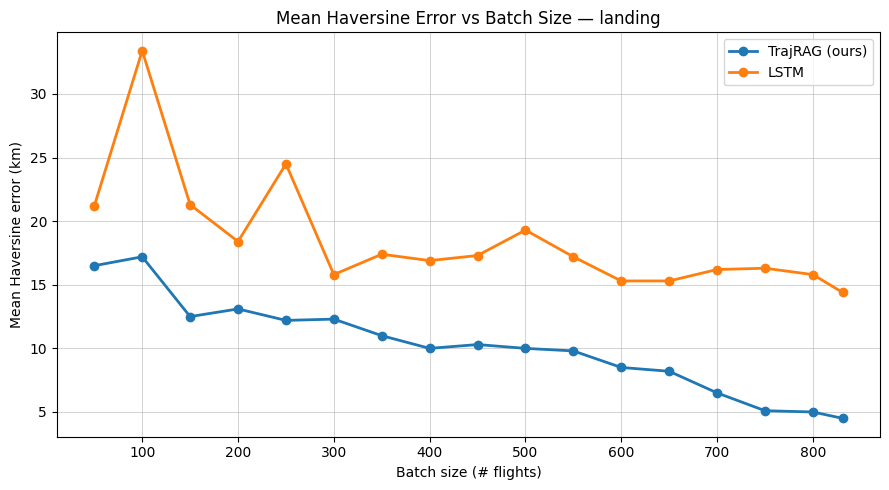

In [1]:
import json
import matplotlib.pyplot as plt

RAG_PATH  = "results_RAG.json"
LSTM_PATH = "results_LSTM.json"

PHASES = ["take_off", "cruising", "landing"]

# --------------------------
# Load JSON
# --------------------------
with open(RAG_PATH, "r", encoding="utf-8") as f:
    rag_data = json.load(f)

with open(LSTM_PATH, "r", encoding="utf-8") as f:
    lstm_data = json.load(f)

# --------------------------
# Normalize to a common structure
# - RAG might be either:
#   A) {"50": {"take_off": {"error": ...}, ...}, ...}
#   B) {"results":[{"sample_size":50,"RAG":{"take_off":...}} ...]}
# --------------------------
def parse_rag(rag_obj):
    # Case A: dict keyed by sizes as strings
    if isinstance(rag_obj, dict) and "results" not in rag_obj:
        parsed = {}
        for k, v in rag_obj.items():
            s = int(k)
            parsed[s] = {p: float(v[p]["error"]) for p in PHASES}
        return parsed

    # Case B: same format as LSTM results.json
    parsed = {}
    for rec in rag_obj.get("results", []):
        s = int(rec["sample_size"])
        parsed[s] = {p: float(rec["RAG"][p]) for p in PHASES}
    return parsed

def parse_lstm(lstm_obj):
    parsed = {}
    for rec in lstm_obj.get("results", []):
        s = int(rec["sample_size"])
        parsed[s] = {p: float(rec["LSTM"][p]) for p in PHASES}
    return parsed

rag_by_size  = parse_rag(rag_data)
lstm_by_size = parse_lstm(lstm_data)

# Use only sizes present in both
common_sizes = sorted(set(rag_by_size.keys()) & set(lstm_by_size.keys()))

# --------------------------
# Plot: one figure per phase
# --------------------------
for phase in PHASES:
    x = common_sizes
    y_rag  = [rag_by_size[s][phase] for s in x]
    y_lstm = [lstm_by_size[s][phase] for s in x]

    plt.figure(figsize=(9, 5))
    plt.plot(x, y_rag,  marker="o", linewidth=2, label="TrajRAG (ours)")
    plt.plot(x, y_lstm, marker="o", linewidth=2, label="LSTM")

    plt.title(f"Mean Haversine Error vs Batch Size — {phase}")
    plt.xlabel("Batch size (# flights)")
    plt.ylabel("Mean Haversine error (km)")
    plt.grid(True, linewidth=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\ruben\AppData\Local\Temp\ipykernel_7808\3692766796.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.9])


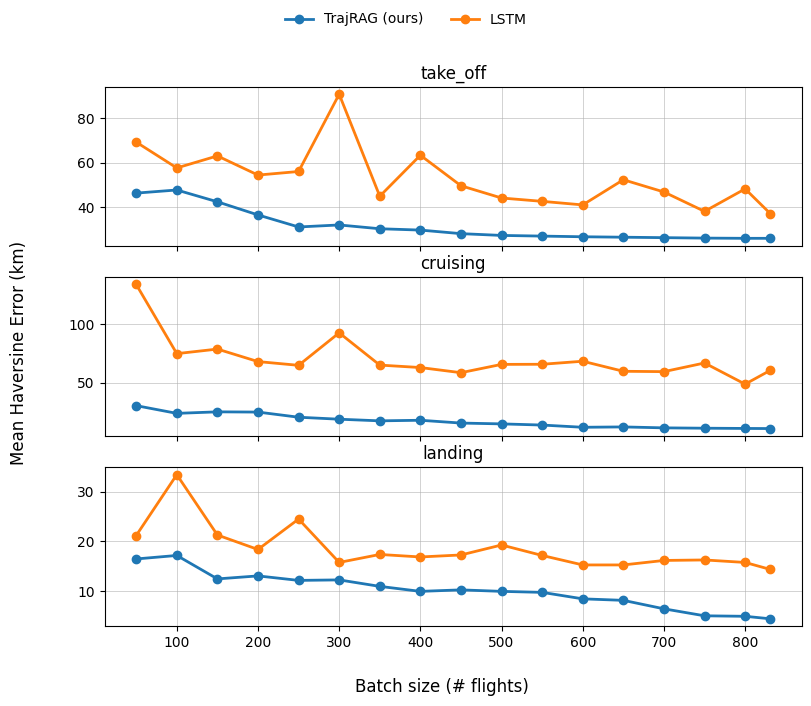

In [16]:
import json
import matplotlib.pyplot as plt

RAG_PATH  = "results_RAG.json"
LSTM_PATH = "results_LSTM.json"

PHASES = ["take_off", "cruising", "landing"]

# --------------------------
# Load JSON
# --------------------------
with open(RAG_PATH, "r", encoding="utf-8") as f:
    rag_data = json.load(f)

with open(LSTM_PATH, "r", encoding="utf-8") as f:
    lstm_data = json.load(f)

# --------------------------
# Normalize structure
# --------------------------
def parse_rag(rag_obj):
    if isinstance(rag_obj, dict) and "results" not in rag_obj:
        parsed = {}
        for k, v in rag_obj.items():
            s = int(k)
            parsed[s] = {p: float(v[p]["error"]) for p in PHASES}
        return parsed

    parsed = {}
    for rec in rag_obj.get("results", []):
        s = int(rec["sample_size"])
        parsed[s] = {p: float(rec["RAG"][p]) for p in PHASES}
    return parsed


def parse_lstm(lstm_obj):
    parsed = {}
    for rec in lstm_obj.get("results", []):
        s = int(rec["sample_size"])
        parsed[s] = {p: float(rec["LSTM"][p]) for p in PHASES}
    return parsed


rag_by_size  = parse_rag(rag_data)
lstm_by_size = parse_lstm(lstm_data)

common_sizes = sorted(set(rag_by_size.keys()) & set(lstm_by_size.keys()))

# --------------------------
# Plot (compact version)
# --------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(9, 7),                 # compact height
    sharex=True,
    gridspec_kw={"hspace": 0.2}    # reduced vertical spacing
)

for idx, phase in enumerate(PHASES):
    ax = axes[idx]

    x = common_sizes
    y_rag  = [rag_by_size[s][phase] for s in x]
    y_lstm = [lstm_by_size[s][phase] for s in x]

    ax.plot(x, y_rag,  marker="o", linewidth=2, label="TrajRAG (ours)")
    ax.plot(x, y_lstm, marker="o", linewidth=2, label="LSTM")

    ax.set_title(phase, fontsize=12)
    ax.grid(True, linewidth=0.4)

# Global labels
fig.supylabel("Mean Haversine Error (km)", fontsize=12)
fig.supxlabel("Batch size (# flights)", fontsize=12)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 0.9, 0.9])
plt.show()
